In [868]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepcontractor/car-price-prediction-challenge/car_price_prediction.csv


In [869]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [870]:
df = pd.read_csv("/kaggle/input/datasets/deepcontractor/car-price-prediction-challenge/car_price_prediction.csv")

In [871]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [872]:
df.shape

(19237, 18)

In [873]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [874]:
df.value_counts('Doors')

Doors
04-May    18332
02-Mar      777
>5          128
Name: count, dtype: int64

In [875]:
df.drop(columns=['ID', 'Model'],inplace= True)

In [876]:
df.head(10)

,Price,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891,HYUNDAI,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,1803,761,TOYOTA,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,549,751,HYUNDAI,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,1098,394,TOYOTA,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,26657,-,LEXUS,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [877]:
df.drop(columns = ['Color'], inplace = True)

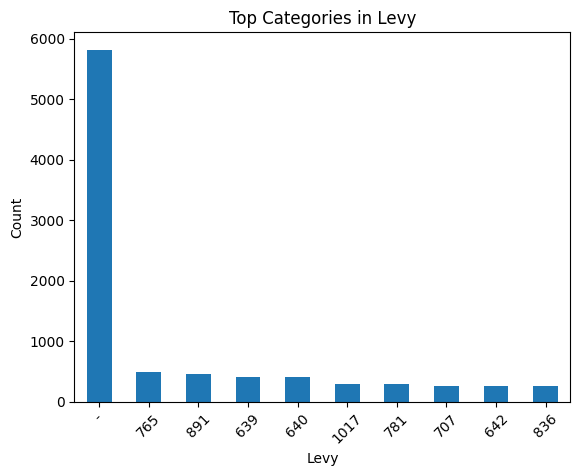

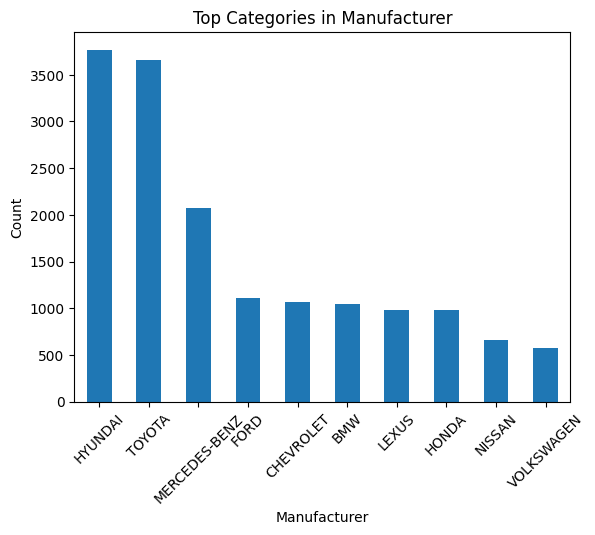

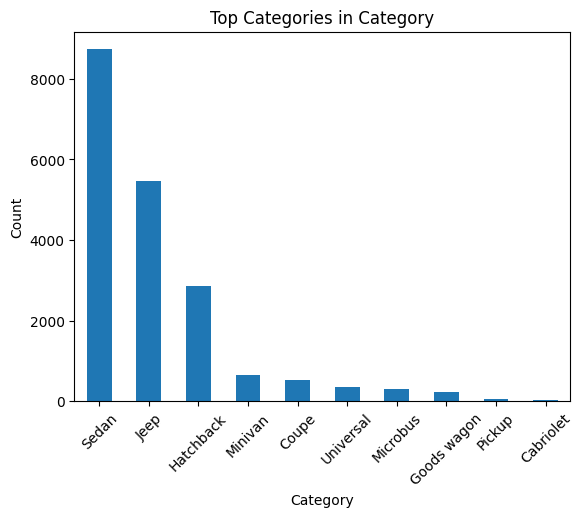

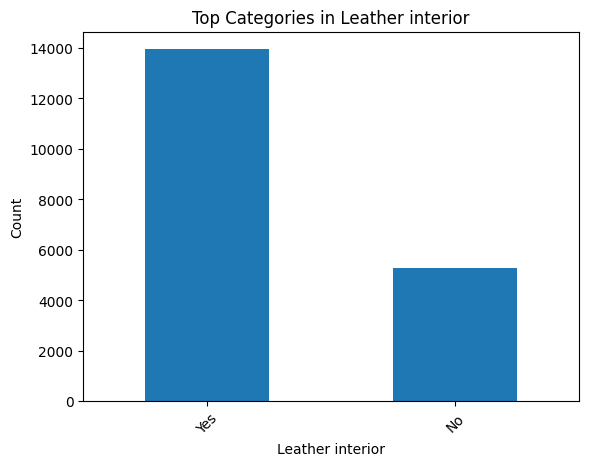

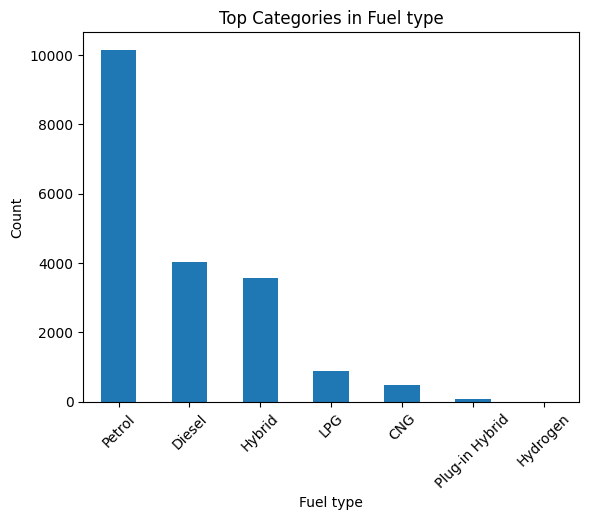

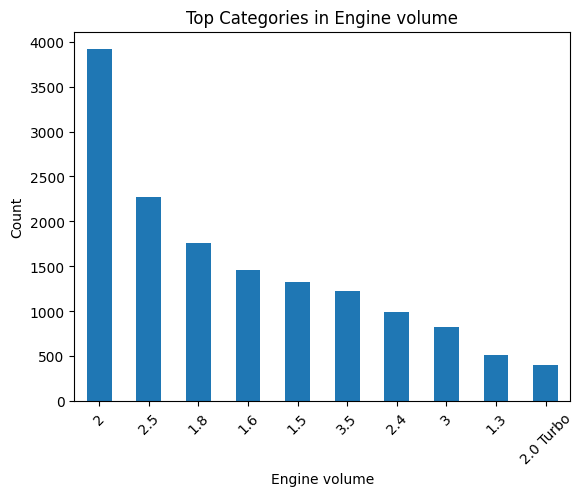

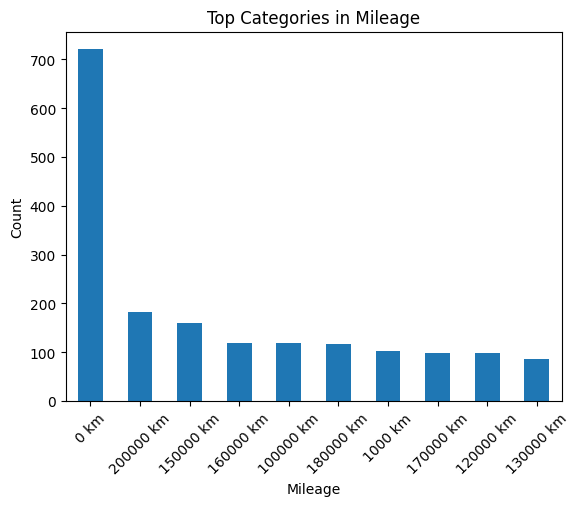

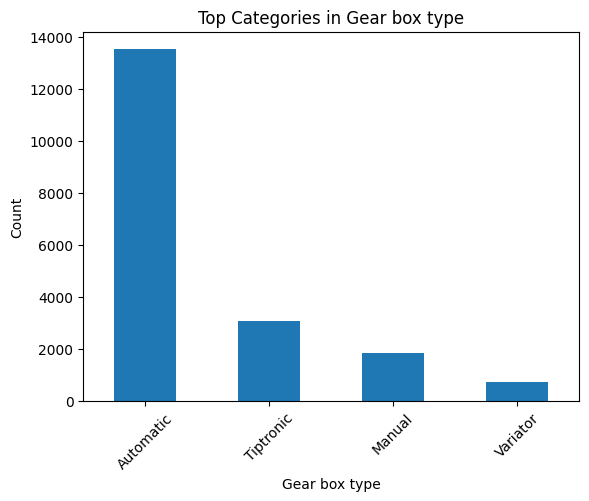

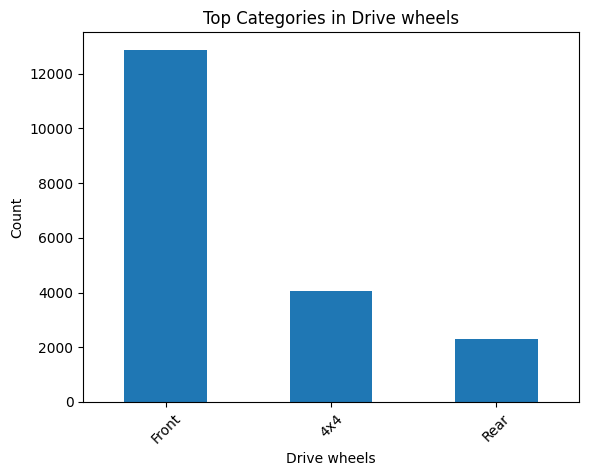

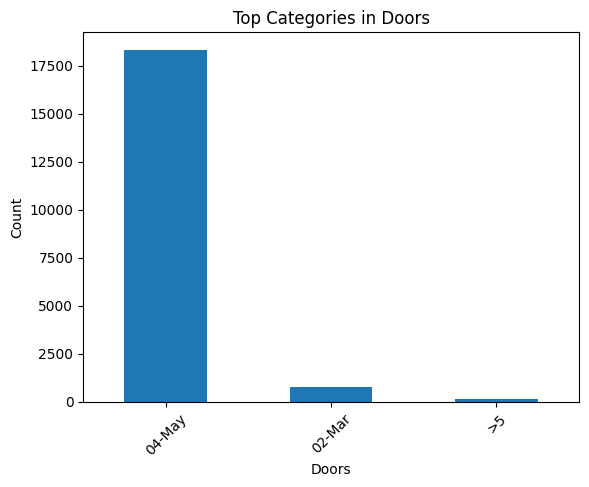

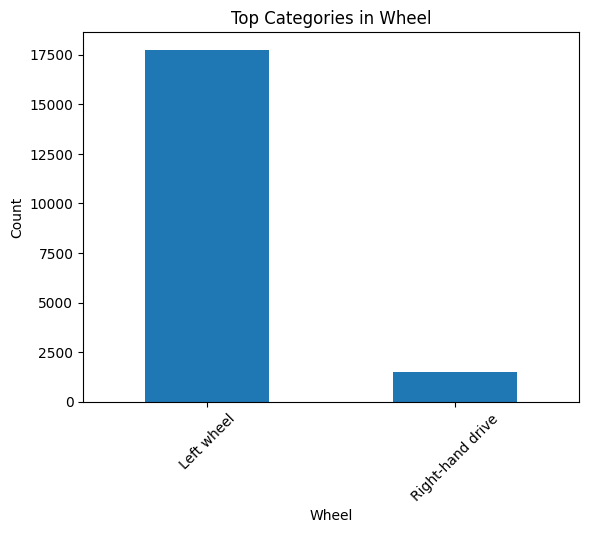

In [878]:
import matplotlib.pyplot as plt

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

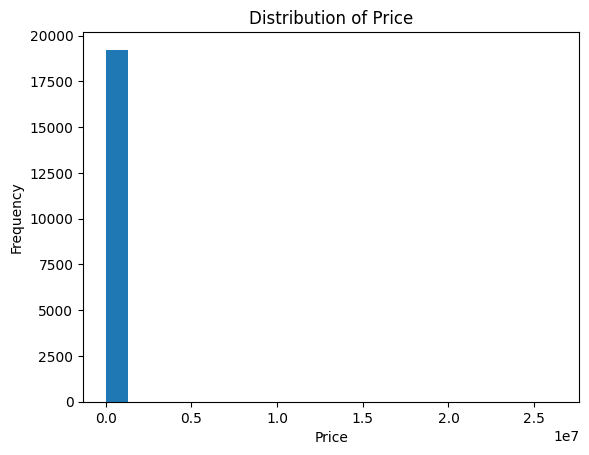

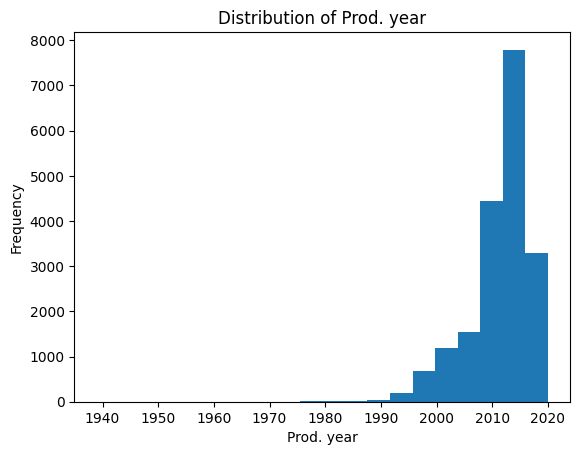

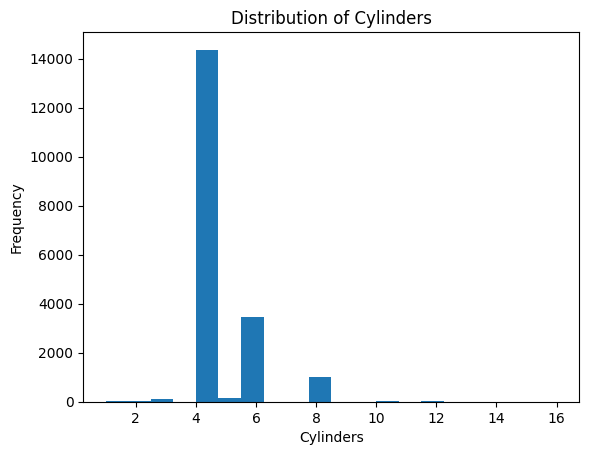

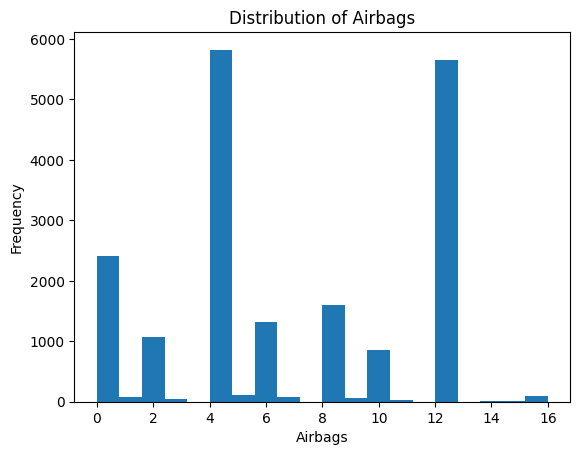

In [879]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    df[col].plot(kind='hist', bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [880]:
df.value_counts('Drive wheels')

Drive wheels
Front    12874
4x4       4058
Rear      2305
Name: count, dtype: int64

In [881]:
df.value_counts('Levy')

Levy
-       5819
765      486
891      461
639      410
640      405
        ... 
972        1
2505       1
2562       1
2570       1
970        1
Name: count, Length: 559, dtype: int64

In [882]:
df.replace('-', np.nan, inplace=True)

In [883]:
df.value_counts('Leather interior')

Leather interior
Yes    13954
No      5283
Name: count, dtype: int64

In [884]:
df.value_counts('Fuel type')

Fuel type
Petrol            10150
Diesel             4036
Hybrid             3578
LPG                 892
CNG                 494
Plug-in Hybrid       86
Hydrogen              1
Name: count, dtype: int64

In [885]:
df.value_counts('Doors')

Doors
04-May    18332
02-Mar      777
>5          128
Name: count, dtype: int64

In [886]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

In [887]:
df['Engine volume'] = df['Engine volume'].astype(str)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '')

df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

In [888]:
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

In [889]:
df['Levy'].fillna(df['Levy'].median(), inplace=True)

/tmp/ipykernel_55/141460907.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Levy'].fillna(df['Levy'].median(), inplace=True)


In [890]:
# cols = ['Mileage', 'Engine volume', 'Levy']

# for col in cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
    
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
    
#     df = df[(df[col] >= lower) & (df[col] <= upper)]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [891]:
df = df[df['Price'] < df['Price'].quantile(0.95)]

In [892]:
df = pd.get_dummies(df, columns=[
    'Category', 
    'Fuel type', 
    'Gear box type', 
    'Drive wheels', 
    'Wheel'
], drop_first=True)

In [893]:
df['Leather interior'] = df['Leather interior'].map({'Yes':1, 'No':0})

In [894]:
le = LabelEncoder()
df['Manufacturer'] = le.fit_transform(df['Manufacturer'])

In [895]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [896]:
mapping = {
    "02-Mar": 2,
    "04-May": 4,
    ">5": 6
}

df['Doors_cleaned'] = df['Doors'].map(mapping)

In [897]:
df['Doors_cleaned'] = df['Doors'].apply(clean_doors)

In [898]:
df.drop(columns = ['Doors'], inplace = True)

In [899]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [900]:
df['car_age'] = 2026 - df['Prod. year']
df.drop(columns=['Prod. year'], inplace=True)

In [902]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [903]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [904]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [905]:
df.head()

,Price,Levy,Manufacturer,Leather interior,Engine volume,Mileage,Cylinders,Airbags,Category_Coupe,Category_Goods wagon,...,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear,Wheel_Right-hand drive,Doors_cleaned,car_age,engine_per_cylinder
0,13328,1197.5,29,1,3.5,186005.0,6.0,12,0,0,...,0,0,0,0,0,0,0,4.5,16,0.583333
1,16621,1018.0,6,0,3.0,192000.0,6.0,8,0,0,...,0,0,1,0,0,0,0,4.5,15,0.500000
2,8467,781.0,19,0,1.3,200000.0,4.0,2,0,0,...,0,0,0,1,1,0,1,4.5,20,0.325000
3,3607,862.0,14,1,2.5,168966.0,4.0,0,0,0,...,0,0,0,0,0,0,0,4.5,15,0.625000
4,11726,449.5,19,1,1.3,91901.0,4.0,4,0,0,...,0,0,0,0,1,0,0,4.5,12,0.325000


In [906]:
from sklearn.neighbors import KNeighborsRegressor


knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)

KNeighborsRegressor(weights='distance')

In [907]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = knn.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7019622689117102
MSE: 42927414.2646687


In [908]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"K={k}, R2={r2_score(y_test, y_pred)}")

K=1, R2=0.5762288239661473
K=2, R2=0.6546814215383847
K=3, R2=0.6720824377298604
K=4, R2=0.6743263014465988
K=5, R2=0.6717121722619541
K=6, R2=0.6656755176127618
K=7, R2=0.6607911524462753
K=8, R2=0.6577538975864523
K=9, R2=0.6525520262830384
K=10, R2=0.6525151891101355
K=11, R2=0.6493228433610716
K=12, R2=0.6426108561518205
K=13, R2=0.6402600673438964
K=14, R2=0.6364745260292309
K=15, R2=0.6344193801142499
K=16, R2=0.6318346198891471
K=17, R2=0.628567771710417
K=18, R2=0.626576307096357
K=19, R2=0.6228809754585298
K=20, R2=0.6201969650065595


In [909]:
df.head(10)

,Price,Levy,Manufacturer,Leather interior,Engine volume,Mileage,Cylinders,Airbags,Category_Coupe,Category_Goods wagon,...,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear,Wheel_Right-hand drive,Doors_cleaned,car_age,engine_per_cylinder
0,13328,1197.5,29,1,3.5,186005.0,6.0,12,0,0,...,0,0,0,0,0,0,0,4.5,16,0.583333
1,16621,1018.0,6,0,3.0,192000.0,6.0,8,0,0,...,0,0,1,0,0,0,0,4.5,15,0.500000
2,8467,781.0,19,0,1.3,200000.0,4.0,2,0,0,...,0,0,0,1,1,0,1,4.5,20,0.325000
3,3607,862.0,14,1,2.5,168966.0,4.0,0,0,0,...,0,0,0,0,0,0,0,4.5,15,0.625000
4,11726,449.5,19,1,1.3,91901.0,4.0,4,0,0,...,0,0,0,0,1,0,0,4.5,12,0.325000
5,39493,891.0,21,1,2.0,160931.0,4.0,4,0,0,...,0,0,0,0,1,0,0,4.5,10,0.500000
6,1803,761.0,54,1,1.8,258909.0,4.0,12,0,0,...,0,0,0,0,1,0,0,4.5,16,0.450000
7,549,751.0,21,1,2.4,216118.0,4.0,12,0,0,...,0,0,0,0,1,0,0,4.5,13,0.600000
8,1098,449.5,54,1,2.5,367011.5,4.0,12,0,0,...,0,0,0,0,1,0,0,4.5,12,0.625000
9,26657,781.0,29,1,3.5,128500.0,6.0,12,0,0,...,0,0,0,0,0,0,0,4.5,19,0.583333


In [910]:
df.shape

(18274, 33)

In [911]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

R2: 0.7557615296932794
MSE: 35178519.028249085
